# X-TBWISA validation notebook for DIF-PI

This notebook validates the X-TBWISA explainability module used in the DIF-PI framework and aligns the evaluation with the experiments from the paper “X-TBWISA: Explainable What-If Scenario Generation Using Transformers and SHAP Guidance.

## What this notebook does

1. loads the processed daily SKU panel created by the preprocessing workflow;
2. reuses the saved `TEST_SKUs` split from the shared forecaster artifacts, when present;
3. fits TBWISA on each evaluation SKU and rolls all intervention scenarios through the same saved global forecaster;
4. builds the X-TBWISA surrogate dataset from scenario histories and teacher forecasts;
5. trains an XGBoost surrogate and evaluates surrogate fidelity with MAE and RMSE;
6. computes TreeSHAP global and local explanations;
7. evaluates adjacent-delta SHAP drift, price-feature drift, monotonicity, and price-alignment;
8. assigns *Accept / Accept_Caution / Flag* labels under a reproducible screening policy;
9. exports paper-ready tables and figures for direct insertion into the thesis.

## Input

- processed panel: `difpi_pricing_demand_panel.csv`
- saved global forecaster artifact
- saved `test_skus.csv` split when available
- DIF-PI scenario modules:
  - `tbwisa.py`
  - `transformer_forecaster.py`

## Output

Notebook exports the following thesis-ready files into `artifacts/x_tbwisa_validation_outputs/`:

- `x_tbwisa_fidelity.csv`
- `x_tbwisa_screening_summary.csv`
- `x_tbwisa_status_distribution.csv`
- `x_tbwisa_global_shap.csv`
- `x_tbwisa_fidelity.png`
- `x_tbwisa_global_shap.png`
- `x_tbwisa_local_waterfall.png`
- `x_tbwisa_adjacent_delta_drift.png`
- `x_tbwisa_screening_outcomes.png`


In [ ]:
from pathlib import Path
import json
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgbregressor
import shap

REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

try:
    from tbwisa import TBWISAGenerator
    from transformer_forecaster import ScenarioGenerationTransformerForecaster
except Exception:
    from src.tbwisa import TBWISAGenerator
    from src.transformer_forecaster import ScenarioGenerationTransformerForecaster

## Configuration

Update the paths below only if your processed data or saved artifacts live in a different location.


In [ ]:
# Paths
PANEL_PATH = REPO_ROOT / "datasets" / "processed" / "difpi_pricing_demand_panel.csv"

FORECASTER_DIR_CANDIDATES = [
    REPO_ROOT / "artifacts" / "models" / "scenario_gen_transformer_global",
    REPO_ROOT / "artifacts" / "scenario_generation_transformer_artifact",
]

TEST_SKUS_PATH_CANDIDATES = [p / "test_skus.csv" for p in FORECASTER_DIR_CANDIDATES]

OUT_DIR = REPO_ROOT / "artifacts" / "x_tbwisa_validation_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Standardized columns
SKU_COL = "StockCode"
TIME_COL = "timestamp"
PRICE_COL = "price"
DEMAND_COL = "demand"

# Evaluation settings
DELTA_GRID = [-15, -10, -5, 0, 5, 10, 15]
HORIZON = 30
TRAIN_FRAC = 0.80
MAX_EVAL_SKUS = 60
MIN_HISTORY = 120

# Shared forecaster defaults (used only if no artifact is found)
FORECASTER_SEQ_LEN = 30
FORECASTER_MIN_POINTS = 60

# TBWISA controlled elasticity settings
TBWISA_CFG = dict(
    seasonal_periods=(7.0, 365.25),
    eps=1e-9,
    prior_eps=0.05,
    use_event=True,
    price_change_pct_thresh=0.01,
    huber_epsilon=1.35,
    huber_alpha=1e-4,
    min_fit_rows=30,
    elast_max_abs=5.0,
)

# X-TBWISA settings
INTENT_WEIGHT = 1.0          # keep timing influence neutral in standalone X-TBWISA validation
DRIFT_Q = 0.75               # 75th percentile threshold, aligned with the bulletin article
MONO_TOL_REL = 0.02
ALIGN_TOL = 0.0
PRICE_FEATURES = ["delta_pct", "last_price"]

# Surrogate settings
SURROGATE_CFG = dict(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=4,
)

## Utilities

In [ ]:
def load_panel(panel_path: Path) -> pd.DataFrame:
    df = pd.read_csv(panel_path)
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])
    df[SKU_COL] = df[SKU_COL].astype(str)
    df = df.sort_values([SKU_COL, TIME_COL]).reset_index(drop=True)
    return df


def get_eval_skus(panel_df: pd.DataFrame, max_eval_skus: int = 25, min_history: int = 120):
    stats = (
        panel_df.groupby(SKU_COL)
        .agg(
            n_points=(DEMAND_COL, "size"),
            active_days=(DEMAND_COL, lambda s: int((pd.Series(s) > 0).sum())),
            mean_demand=(DEMAND_COL, "mean"),
        )
        .reset_index()
    )
    stats[SKU_COL] = stats[SKU_COL].astype(str)
    stats = stats[stats["n_points"] >= int(min_history)].copy()
    stats = stats.sort_values(["active_days", "n_points", "mean_demand"], ascending=False)
    return stats.head(int(max_eval_skus))[SKU_COL].astype(str).tolist(), stats


def load_saved_test_skus(path_candidates):
    for p in path_candidates:
        if p.exists():
            try:
                df = pd.read_csv(p)
                first_col = df.columns[0]
                vals = df[first_col].astype(str).dropna().tolist()
                if len(vals):
                    return vals, p
            except Exception as exc:
                print(f"Could not read saved TEST_SKUs from {p}: {exc}")
    return None, None


def select_eval_skus(panel_df: pd.DataFrame, max_eval_skus: int = 25, min_history: int = 120):
    fallback_skus, stats = get_eval_skus(panel_df, max_eval_skus=max_eval_skus, min_history=min_history)

    saved_test_skus, saved_path = load_saved_test_skus(TEST_SKUS_PATH_CANDIDATES)
    if not saved_test_skus:
        print("Saved TEST_SKUs not found. Falling back to notebook-local SKU ranking.")
        return fallback_skus, stats, None

    eligible_stats = stats[stats[SKU_COL].astype(str).isin(saved_test_skus)].copy()
    if eligible_stats.empty:
        print(f"Saved TEST_SKUs found at {saved_path}, but none matched the current eligible panel. Falling back.")
        return fallback_skus, stats, saved_path

    eligible_stats = eligible_stats.sort_values(["active_days", "n_points", "mean_demand"], ascending=False)
    eval_skus = eligible_stats.head(int(max_eval_skus))[SKU_COL].astype(str).tolist()
    return eval_skus, eligible_stats, saved_path


def split_history_future(sku_df: pd.DataFrame, train_frac: float = 0.8, horizon: int = 30):
    sku_df = sku_df.sort_values(TIME_COL).reset_index(drop=True)
    n = len(sku_df)
    cut = max(int(np.floor(n * float(train_frac))), FORECASTER_MIN_POINTS)
    cut = min(cut, n - int(horizon))
    hist = sku_df.iloc[:cut].copy()
    fut = sku_df.iloc[cut:cut + int(horizon)].copy()
    return hist, fut


def _daily_future_index(last_ts, horizon):
    last_ts = pd.to_datetime(last_ts)
    return pd.date_range(start=last_ts + pd.Timedelta(days=1), periods=horizon, freq="D")


def _resolve_forecaster_dir():
    for p in FORECASTER_DIR_CANDIDATES:
        if p.exists():
            return p
    return FORECASTER_DIR_CANDIDATES[0]


def load_or_train_forecaster(panel_df: pd.DataFrame):
    chosen_dir = _resolve_forecaster_dir()
    if chosen_dir.exists():
        try:
            model = ScenarioGenerationTransformerForecaster.load(str(chosen_dir))
            print(f"Loaded saved forecaster from: {chosen_dir}")
            return model
        except Exception as exc:
            print(f"Could not load saved forecaster from {chosen_dir}: {exc}. Training a temporary model instead...")

    train_skus, _ = get_eval_skus(panel_df, max_eval_skus=60, min_history=MIN_HISTORY)
    forecaster = ScenarioGenerationTransformerForecaster(
        sequence_length=30,
        size_layer=64,
        embedded_size=64,
        output_size=1,
        num_heads=8,
        dropout_rate=0.1,
    )
    info = forecaster.fit_global(
        panel_df=panel_df,
        sku_col=SKU_COL,
        time_col=TIME_COL,
        target_col=DEMAND_COL,
        train_skus=train_skus,
        batch_size=64,
        epochs=10,
        learning_rate=1e-3,
        per_sku_train_frac=TRAIN_FRAC,
        min_points=FORECASTER_MIN_POINTS,
        verbose=0,
    )
    chosen_dir.mkdir(parents=True, exist_ok=True)
    forecaster.save(str(chosen_dir))
    print("Temporary forecaster training info:", info)
    return forecaster


def fit_tbwisa():
    gen = TBWISAGenerator()
    gen.configure_controlled_elasticity(**TBWISA_CFG)
    return gen


def generate_scenarios_tbwisa(gen: TBWISAGenerator, hist_df: pd.DataFrame, deltas):
    inp, out = gen.generate_scenarios(hist_df[[PRICE_COL, DEMAND_COL]].copy(), PRICE_COL, DEMAND_COL, deltas)
    scenarios = {}
    for delta in deltas:
        name = f"{PRICE_COL} change {delta}%"
        scenarios[int(delta)] = pd.DataFrame({
            TIME_COL: hist_df[TIME_COL].values,
            PRICE_COL: np.asarray(inp[name], float),
            DEMAND_COL: np.asarray(out[name], float),
        })
    return scenarios, getattr(gen, "_last_elasticity_meta", {})


def rollout_scenarios(forecaster, scenario_dict, horizon: int):
    rolled = {}
    for delta, scen_df in scenario_dict.items():
        hist_d = scen_df[DEMAND_COL].astype(float).values
        future_d = forecaster.forecast(hist_d, forecast_length=horizon)
        last_price = float(scen_df[PRICE_COL].iloc[-1])
        future_price = np.full(int(horizon), last_price)
        rolled[int(delta)] = {
            "history_df": scen_df.copy(),
            "future_index": _daily_future_index(scen_df[TIME_COL].iloc[-1], horizon),
            "future_price": future_price,
            "future_demand": np.asarray(future_d, float),
            "future_revenue": future_price * np.asarray(future_d, float),
        }
    return rolled


def evaluate_windows(rolled_dict, min_window=7, max_window=30, penalty=0.0):
    helper = TBWISAGenerator()
    rows = []
    for d, payload in rolled_dict.items():
        best = helper.best_window(payload["future_revenue"], min_len=min_window, max_len=max_window, length_penalty=penalty)
        rows.append({
            "delta_pct": int(d),
            "start": int(best["start"]),
            "end": int(best["end"]),
            "length": int(best["len"]),
            "avg_revenue": float(best["avg"]),
            "score": float(best["score"]),
        })
    return pd.DataFrame(rows).sort_values("delta_pct").reset_index(drop=True)


def build_surrogate_dataset(rolled_dict, sku):
    rows = []
    for delta, payload in rolled_dict.items():
        hist_df = payload["history_df"]
        teacher = np.asarray(payload["future_demand"], float) * float(INTENT_WEIGHT)

        last_price = float(hist_df[PRICE_COL].iloc[-1])
        last_demand = float(hist_df[DEMAND_COL].iloc[-1])
        mean14 = float(np.mean(hist_df[DEMAND_COL].tail(14)))
        std14 = float(np.std(hist_df[DEMAND_COL].tail(14)))
        trend7 = float(hist_df[DEMAND_COL].iloc[-1] - hist_df[DEMAND_COL].iloc[-7]) if len(hist_df) >= 7 else 0.0

        for t in range(len(teacher)):
            rows.append({
                "sku": str(sku),
                "delta_pct": int(delta),
                "step": int(t + 1),
                "last_price": last_price,
                "last_demand": last_demand,
                "mean14_demand": mean14,
                "std14_demand": std14,
                "trend7_demand": trend7,
                "teacher_demand_t": float(teacher[t]),
            })
    return pd.DataFrame(rows)


def _safe_corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    if len(x) < 3 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def compute_window_phi(sur_df, shap_vals, windows_m, features, ref_window=None, use_ref_for_all=True):
    win_map = {int(r.delta_pct): (int(r.start), int(r.length)) for r in windows_m.itertuples(index=False)}

    if ref_window is None:
        if "score" in windows_m.columns and len(windows_m):
            best = windows_m.sort_values("score", ascending=False).iloc[0]
            ref_window = (int(best["start"]), int(best["length"]))
        else:
            starts = [v[0] for v in win_map.values()]
            lens = [v[1] for v in win_map.values()]
            ref_window = (int(pd.Series(starts).mode().iloc[0]), int(pd.Series(lens).mode().iloc[0]))

    ref_start, ref_L = ref_window
    phi = {}

    for delta in sorted(win_map):
        if use_ref_for_all:
            start, L = ref_start, ref_L
        else:
            start, L = win_map[int(delta)]

        mask = (
            (sur_df["delta_pct"].astype(int) == int(delta))
            & (sur_df["step"] > start)
            & (sur_df["step"] <= start + L)
        )
        if mask.sum() == 0:
            mask = sur_df["delta_pct"].astype(int) == int(delta)
        phi[int(delta)] = np.mean(shap_vals[mask.values, :], axis=0).astype(float)

    return phi, win_map, ref_window


def shap_drift(phi_map, deltas_sorted, eps=1e-8):
    rows = []
    for a, b in zip(deltas_sorted[:-1], deltas_sorted[1:]):
        va = phi_map[int(a)]
        vb = phi_map[int(b)]
        d = float(np.sum(np.abs(vb - va)) / (np.sum(np.abs(va)) + eps))
        rows.append({"delta_a": int(a), "delta_b": int(b), "dshap": d})
    return pd.DataFrame(rows)


def price_drift_ratio(phi_map, deltas_sorted, features, price_features=PRICE_FEATURES, eps=1e-8):
    price_idx = [features.index(f) for f in price_features if f in features]
    rows = []
    for a, b in zip(deltas_sorted[:-1], deltas_sorted[1:]):
        va = phi_map[int(a)]
        vb = phi_map[int(b)]
        diff = np.abs(vb - va)
        denom = float(np.sum(diff) + eps)
        numer = float(np.sum(diff[price_idx])) if price_idx else 0.0
        rows.append({"delta_a": int(a), "delta_b": int(b), "r_price": float(numer / denom)})
    return pd.DataFrame(rows)


def monotonicity_local_ok(rolled_dict, deltas_sorted, tol_rel=MONO_TOL_REL, tail=30):
    mean_tail = {}
    for d in deltas_sorted:
        y = np.asarray(rolled_dict[int(d)]["future_demand"], float)
        mean_tail[int(d)] = float(np.mean(y[-tail:])) if len(y) else np.nan

    pair_ok = {}
    for a, b in zip(deltas_sorted[:-1], deltas_sorted[1:]):
        ya = mean_tail[int(a)]
        yb = mean_tail[int(b)]
        if np.isnan(ya) or np.isnan(yb):
            pair_ok[(int(a), int(b))] = True
        else:
            pair_ok[(int(a), int(b))] = bool(yb <= ya * (1.0 + tol_rel))

    local_ok = {}
    for i, d in enumerate(deltas_sorted):
        ok_prev = True
        ok_next = True
        if i > 0:
            ok_prev = pair_ok[(int(deltas_sorted[i - 1]), int(d))]
        if i < len(deltas_sorted) - 1:
            ok_next = pair_ok[(int(d), int(deltas_sorted[i + 1]))]
        local_ok[int(d)] = bool(ok_prev and ok_next)

    return local_ok, mean_tail


def alignment_ok(phi_map, deltas_sorted, features, delta_feature="delta_pct", tol=ALIGN_TOL):
    if delta_feature not in features:
        return {int(d): True for d in deltas_sorted}
    j = features.index(delta_feature)
    out = {}
    for d in deltas_sorted:
        d = int(d)
        if d == 0:
            out[d] = True
            continue
        s = float(d) * float(phi_map[d][j])
        out[d] = bool(s <= tol)
    return out


def plausibility_ok(rolled_dict, deltas_sorted):
    corr_map = {}
    for d in deltas_sorted:
        p = np.asarray(rolled_dict[int(d)]["future_price"], float)
        y = np.asarray(rolled_dict[int(d)]["future_demand"], float)
        corr_map[int(d)] = _safe_corr(p, y)
    out = {}
    for d in deltas_sorted:
        c = corr_map[int(d)]
        out[int(d)] = bool(np.isnan(c) or c < 0)
    return out, corr_map


def assign_drift_to_delta(drift_df, ratio_df, deltas_sorted):
    drift_prev = {int(d): np.nan for d in deltas_sorted}
    drift_next = {int(d): np.nan for d in deltas_sorted}
    r_prev = {int(d): np.nan for d in deltas_sorted}
    r_next = {int(d): np.nan for d in deltas_sorted}

    for r in drift_df.itertuples(index=False):
        a, b, dsh = int(r.delta_a), int(r.delta_b), float(r.dshap)
        drift_next[a] = dsh
        drift_prev[b] = dsh

    for r in ratio_df.itertuples(index=False):
        a, b, rp = int(r.delta_a), int(r.delta_b), float(r.r_price)
        r_next[a] = rp
        r_prev[b] = rp

    max_drift = {}
    max_rprice = {}
    for d in deltas_sorted:
        candidates = []
        if not np.isnan(drift_prev[int(d)]):
            candidates.append((drift_prev[int(d)], r_prev[int(d)]))
        if not np.isnan(drift_next[int(d)]):
            candidates.append((drift_next[int(d)], r_next[int(d)]))
        if len(candidates) == 0:
            max_drift[int(d)] = np.nan
            max_rprice[int(d)] = np.nan
        else:
            md, mr = sorted(candidates, key=lambda x: x[0], reverse=True)[0]
            max_drift[int(d)] = float(md)
            max_rprice[int(d)] = float(mr)
    return max_drift, max_rprice


def x_tbwisa_flagging_for_sku(sur_df_sku, shap_vals_sku, windows_m, features, rolled_dict):
    deltas_sorted = sorted([int(d) for d in rolled_dict.keys()])
    phi_map, win_map, ref_window = compute_window_phi(sur_df_sku, shap_vals_sku, windows_m, features, ref_window=None, use_ref_for_all=True)

    drift_df = shap_drift(phi_map, deltas_sorted)
    ratio_df = price_drift_ratio(phi_map, deltas_sorted, features, price_features=PRICE_FEATURES)

    tau_drift = float(np.quantile(drift_df["dshap"].values, DRIFT_Q)) if len(drift_df) else np.nan
    tau_price = float(np.quantile(ratio_df["r_price"].values, DRIFT_Q)) if len(ratio_df) else np.nan

    align = alignment_ok(phi_map, deltas_sorted, features)
    mono_local, mean_tail = monotonicity_local_ok(rolled_dict, deltas_sorted)
    plaus, corr_map = plausibility_ok(rolled_dict, deltas_sorted)

    max_drift, max_rprice = assign_drift_to_delta(drift_df, ratio_df, deltas_sorted)

    rows = []
    for d in deltas_sorted:
        drift_flag = (not np.isnan(max_drift[d])) and (not np.isnan(tau_drift)) and (max_drift[d] > tau_drift)
        econ_ok = bool(mono_local[d] and align[d] and plaus[d])

        reasons = []
        if drift_flag:
            if (not np.isnan(max_rprice[d])) and (not np.isnan(tau_price)) and (max_rprice[d] > tau_price):
                reasons.append("high_shap_drift_price_dominated")
            else:
                reasons.append("high_shap_drift")
        if not mono_local[d]:
            reasons.append("monotonicity_fail")
        if not align[d]:
            reasons.append("price_alignment_fail")
        if not plaus[d]:
            reasons.append("economic_plausibility_fail")

        if drift_flag:
            status = "Flag"
        elif econ_ok:
            status = "Accept"
        else:
            status = "Accept_Caution"

        rows.append({
            "delta_pct": int(d),
            "window_start_offset_days": int(win_map[int(d)][0]),
            "window_length_days": int(win_map[int(d)][1]),
            "status": status,
            "reason": ",".join(reasons) if reasons else "ok",
            "economic_ok": bool(econ_ok),
            "aligned": bool(align[d]),
            "monotone_local": bool(mono_local[d]),
            "plausible": bool(plaus[d]),
            "corr_price_demand_hist": float(corr_map[int(d)]) if corr_map[int(d)] is not None else np.nan,
            "dshap_max": float(max_drift[d]) if not np.isnan(max_drift[d]) else np.nan,
            "r_price_max": float(max_rprice[d]) if not np.isnan(max_rprice[d]) else np.nan,
            "tau_drift": float(tau_drift) if not np.isnan(tau_drift) else np.nan,
            "tau_price": float(tau_price) if not np.isnan(tau_price) else np.nan,
            "ref_window_start": int(ref_window[0]),
            "ref_window_length": int(ref_window[1]),
        })
    return (
        pd.DataFrame(rows).sort_values("delta_pct").reset_index(drop=True),
        drift_df,
        ratio_df,
        phi_map,
        ref_window,
    )

## Load panel and shared forecaster

In [ ]:
panel_df = load_panel(PANEL_PATH)
EVAL_SKUS, sku_stats, saved_test_skus_path = select_eval_skus(
    panel_df,
    max_eval_skus=MAX_EVAL_SKUS,
    min_history=MIN_HISTORY,
)
forecaster = load_or_train_forecaster(panel_df)

print(f"Loaded panel shape: {panel_df.shape}")
print(f"Evaluation SKUs: {len(EVAL_SKUS)}")
if saved_test_skus_path is not None:
    print(f"Using saved TEST_SKUs from: {saved_test_skus_path}")
else:
    print("Using notebook-local fallback SKU selection (saved TEST_SKUs not found).")
display(sku_stats.head(10))

Loaded saved forecaster from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/scenario_gen_transformer_global
Loaded panel shape: (209633, 4)
Evaluation SKUs: 60
Using saved TEST_SKUs from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/scenario_gen_transformer_global/test_skus.csv


,StockCode,n_points,active_days,mean_demand
24,1029743,710,708,23.904225
281,981760,711,705,15.790436
152,840361,709,693,8.547250
78,1098066,711,690,9.383966
233,923746,710,690,7.984507
97,1126899,710,689,7.739437
73,1085604,710,684,4.921127
77,1096036,709,672,5.606488
215,908531,708,661,10.254237
111,5568378,702,650,4.094017


## Run the X-TBWISA benchmark

This block builds TBWISA scenarios on the held-out evaluation SKUs, rolls them forward with the shared global forecaster, constructs the surrogate dataset, fits the XGBoost surrogate, computes TreeSHAP explanations, and then applies the X-TBWISA screening logic.


In [ ]:
surrogate_rows = []
window_rows = []
screening_rows = []
drift_rows = []
ratio_rows = []
case_payload = None

for i, sku in enumerate(EVAL_SKUS, start=1):
    sku_df = panel_df.loc[panel_df[SKU_COL].astype(str) == str(sku)].copy()
    hist_df, fut_df = split_history_future(sku_df, train_frac=TRAIN_FRAC, horizon=HORIZON)
    if len(hist_df) < MIN_HISTORY or len(fut_df) < HORIZON:
        continue

    tb = fit_tbwisa()
    tb_scen, tb_meta = generate_scenarios_tbwisa(tb, hist_df, DELTA_GRID)
    tb_roll = rollout_scenarios(forecaster, tb_scen, HORIZON)
    win_df = evaluate_windows(tb_roll, min_window=7, max_window=30, penalty=0.0)
    win_df.insert(0, "sku", str(sku))
    window_rows.append(win_df)

    sur_sku = build_surrogate_dataset(tb_roll, sku=str(sku))
    surrogate_rows.append(sur_sku)

    if case_payload is None:
        case_payload = {
            "sku": str(sku),
            "hist_df": hist_df.copy(),
            "fut_df": fut_df.copy(),
            "tb_roll": tb_roll,
            "tb_meta": tb_meta,
        }

sur_df = pd.concat(surrogate_rows, ignore_index=True)
windows_df = pd.concat(window_rows, ignore_index=True)

FEATURES = [c for c in sur_df.columns if c not in ["teacher_demand_t", "sku"]]
X = sur_df[FEATURES].values
y = sur_df["teacher_demand_t"].values

# Keep delta and sku information for grouped evaluation after train/test split
row_index = np.arange(len(sur_df))
idx_tr, idx_te = train_test_split(row_index, test_size=0.25, random_state=42)
Xtr = sur_df.iloc[idx_tr][FEATURES].values
ytr = sur_df.iloc[idx_tr]["teacher_demand_t"].values
Xte = sur_df.iloc[idx_te][FEATURES].values
yte = sur_df.iloc[idx_te]["teacher_demand_t"].values
sur_te = sur_df.iloc[idx_te].copy()

surrogate = xgbregressor.XGBRegressor(**SURROGATE_CFG)
surrogate.fit(Xtr, ytr)
pred_te = surrogate.predict(Xte)

overall_mae = float(mean_absolute_error(yte, pred_te))
overall_rmse = float(np.sqrt(mean_squared_error(yte, pred_te)))
print("Overall surrogate fidelity -> MAE:", overall_mae, "| RMSE:", overall_rmse)

sur_te["pred"] = pred_te
fidelity_by_delta = (
    sur_te.groupby("delta_pct")
    .apply(lambda g: pd.Series({
        "n_test": int(len(g)),
        "mae": float(mean_absolute_error(g["teacher_demand_t"], g["pred"])),
        "rmse": float(np.sqrt(mean_squared_error(g["teacher_demand_t"], g["pred"]))),
    }))
    .reset_index()
    .sort_values("delta_pct")
    .reset_index(drop=True)
)

explainer = shap.TreeExplainer(surrogate)
shap_vals = explainer.shap_values(sur_df[FEATURES])
global_imp = (
    pd.DataFrame({
        "feature": FEATURES,
        "mean_abs_shap": np.mean(np.abs(shap_vals), axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

# Per-SKU screening on the same held-out SKU pool
for sku, sur_sku in sur_df.groupby("sku"):
    mask = sur_df["sku"].astype(str) == str(sku)
    shap_sku = shap_vals[mask.values, :]
    win_sku = windows_df.loc[windows_df["sku"].astype(str) == str(sku)].copy()
    if len(win_sku) == 0:
        continue

    # rebuild rolled dict for this sku from case data
    sku_df = panel_df.loc[panel_df[SKU_COL].astype(str) == str(sku)].copy()
    hist_df, fut_df = split_history_future(sku_df, train_frac=TRAIN_FRAC, horizon=HORIZON)
    if len(hist_df) < MIN_HISTORY or len(fut_df) < HORIZON:
        continue
    tb = fit_tbwisa()
    tb_scen, _ = generate_scenarios_tbwisa(tb, hist_df, DELTA_GRID)
    tb_roll = rollout_scenarios(forecaster, tb_scen, HORIZON)

    screen_sku, drift_sku, ratio_sku, phi_map_sku, ref_window_sku = x_tbwisa_flagging_for_sku(
        sur_sku.reset_index(drop=True),
        shap_sku,
        win_sku.drop(columns=["sku"]).reset_index(drop=True),
        FEATURES,
        tb_roll,
    )
    screen_sku.insert(0, "sku", str(sku))
    screening_rows.append(screen_sku)

    drift_sku.insert(0, "sku", str(sku))
    drift_rows.append(drift_sku)

    ratio_sku.insert(0, "sku", str(sku))
    ratio_rows.append(ratio_sku)

screening_df = pd.concat(screening_rows, ignore_index=True)
drift_df = pd.concat(drift_rows, ignore_index=True)
ratio_df = pd.concat(ratio_rows, ignore_index=True)

# Paper-ready tables
x_tbwisa_fidelity = fidelity_by_delta[["delta_pct", "n_test", "mae", "rmse"]].copy()

screen_agg = (
    screening_df.groupby("delta_pct")
    .agg(
        dshap=("dshap_max", "mean"),
        economic_ok_rate=("economic_ok", "mean"),
        r_price=("r_price_max", "mean"),
        accept_rate=("status", lambda s: float((pd.Series(s) == "Accept").mean())),
        caution_rate=("status", lambda s: float((pd.Series(s) == "Accept_Caution").mean())),
        flag_rate=("status", lambda s: float((pd.Series(s) == "Flag").mean())),
    )
    .reset_index()
    .sort_values("delta_pct")
)

def _agg_decision(row):
    if row["flag_rate"] >= 0.5:
        return "Flag"
    if row["accept_rate"] >= 0.5:
        return "Accept"
    return "Accept_Caution"

def _agg_reason(row):
    if row["flag_rate"] >= 0.5 and row["r_price"] > screening_df["r_price_max"].quantile(DRIFT_Q):
        return "High SHAP drift (price-dominated)"
    if row["flag_rate"] >= 0.5:
        return "High SHAP drift"
    if row["economic_ok_rate"] < 0.5:
        return "Economic / monotonicity / alignment"
    return "—"

x_tbwisa_screening_summary = screen_agg.copy()
x_tbwisa_screening_summary["economic_screening"] = np.where(
    x_tbwisa_screening_summary["economic_ok_rate"] >= 0.5,
    "OK",
    "FAIL",
)
x_tbwisa_screening_summary["decision"] = x_tbwisa_screening_summary.apply(_agg_decision, axis=1)
x_tbwisa_screening_summary["reason"] = x_tbwisa_screening_summary.apply(_agg_reason, axis=1)
x_tbwisa_screening_summary = x_tbwisa_screening_summary[
    ["delta_pct", "dshap", "economic_screening", "r_price", "decision", "reason"]
]

status_counts = screening_df["status"].value_counts(dropna=False)
x_tbwisa_status_distribution = pd.DataFrame({
    "status": status_counts.index.astype(str),
    "n_decisions": status_counts.values.astype(int),
})
x_tbwisa_status_distribution["share_decisions"] = (
    x_tbwisa_status_distribution["n_decisions"] / max(int(x_tbwisa_status_distribution["n_decisions"].sum()), 1)
)
def _status_interp(s):
    if s == "Accept":
        return "stable and directly actionable"
    if s == "Accept_Caution":
        return "usable, but with audit warnings"
    return "requires review before recommendation"
x_tbwisa_status_distribution["interpretation"] = x_tbwisa_status_distribution["status"].map(_status_interp)

x_tbwisa_global_shap = global_imp.copy()

# Save tables
x_tbwisa_fidelity.to_csv(OUT_DIR / "x_tbwisa_fidelity.csv", index=False)
x_tbwisa_screening_summary.to_csv(OUT_DIR / "x_tbwisa_screening_summary.csv", index=False)
x_tbwisa_status_distribution.to_csv(OUT_DIR / "x_tbwisa_status_distribution.csv", index=False)
x_tbwisa_global_shap.to_csv(OUT_DIR / "x_tbwisa_global_shap.csv", index=False)

# Save raw support files
sur_df.to_csv(OUT_DIR / "x_tbwisa_surrogate_dataset.csv", index=False)
screening_df.to_csv(OUT_DIR / "x_tbwisa_screening_by_sku.csv", index=False)
drift_df.to_csv(OUT_DIR / "x_tbwisa_drift_pairs_by_sku.csv", index=False)
ratio_df.to_csv(OUT_DIR / "x_tbwisa_price_drift_by_sku.csv", index=False)

print("Saved X-TBWISA outputs to", OUT_DIR.resolve())
print("\nSurrogate fidelity across intervention scenarios")
display(x_tbwisa_fidelity)
print("\nDecision screening summary across intervention scenarios")
display(x_tbwisa_screening_summary)
print("\nAggregated X-TBWISA status distribution across held-out decisions")
display(x_tbwisa_status_distribution)
print("\nGlobal TreeSHAP feature importance")
display(x_tbwisa_global_shap.head(12))

Overall surrogate fidelity -> MAE: 1.315964379760008 | RMSE: 10.794519443783143
Saved X-TBWISA outputs to /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/x_tbwisa_validation_outputs

Surrogate fidelity across intervention scenarios


,delta_pct,n_test,mae,rmse
0,-15,452.0,1.870547,13.560475
1,-10,432.0,1.164188,6.547593
2,-5,464.0,0.673482,3.363636
3,0,448.0,2.491014,19.043153
4,5,481.0,0.518248,2.010563
5,10,437.0,0.687784,3.751428
6,15,436.0,1.877438,14.335327



Decision screening summary across intervention scenarios


,delta_pct,dshap,economic_screening,r_price,decision,reason
0,-15,0.038421,FAIL,0.375866,Flag,High SHAP drift
1,-10,0.039645,OK,0.362756,Flag,High SHAP drift
2,-5,0.039127,OK,0.231244,Flag,High SHAP drift
3,0,0.037834,OK,0.241588,Flag,High SHAP drift
4,5,0.019299,FAIL,0.183016,Accept_Caution,Economic / monotonicity / alignment
5,10,0.007071,FAIL,0.321551,Accept_Caution,Economic / monotonicity / alignment
6,15,0.005500,FAIL,0.391480,Accept_Caution,Economic / monotonicity / alignment



Aggregated X-TBWISA status distribution across held-out decisions


,status,n_decisions,share_decisions,interpretation
0,Flag,216,0.514286,requires review before recommendation
1,Accept_Caution,165,0.392857,"usable, but with audit warnings"
2,Accept,39,0.092857,stable and directly actionable



Global TreeSHAP feature importance


,feature,mean_abs_shap
0,last_price,150.192032
1,last_demand,22.565380
2,step,9.915102
3,mean14_demand,6.636015
4,std14_demand,4.747799
5,delta_pct,0.783005
6,trend7_demand,0.132503


## Surrogate fidelity across intervention scenarios

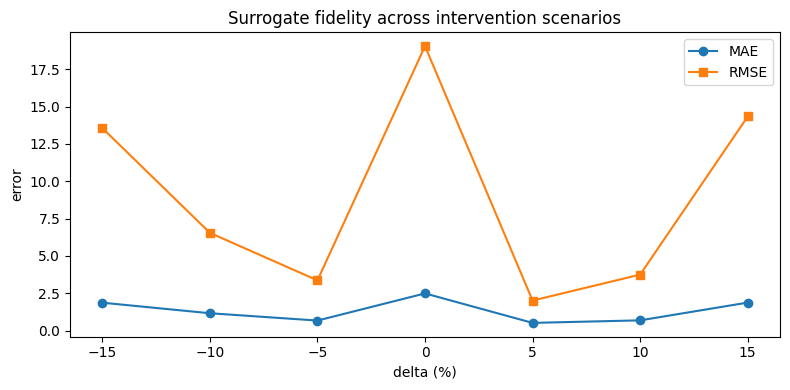

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_tbwisa_fidelity["delta_pct"], x_tbwisa_fidelity["mae"], marker="o", label="MAE")
ax.plot(x_tbwisa_fidelity["delta_pct"], x_tbwisa_fidelity["rmse"], marker="s", label="RMSE")
ax.set_title("Surrogate fidelity across intervention scenarios")
ax.set_xlabel("delta (%)")
ax.set_ylabel("error")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "x_tbwisa_fidelity.png", dpi=160, bbox_inches="tight")
plt.show()

## Global TreeSHAP drivers

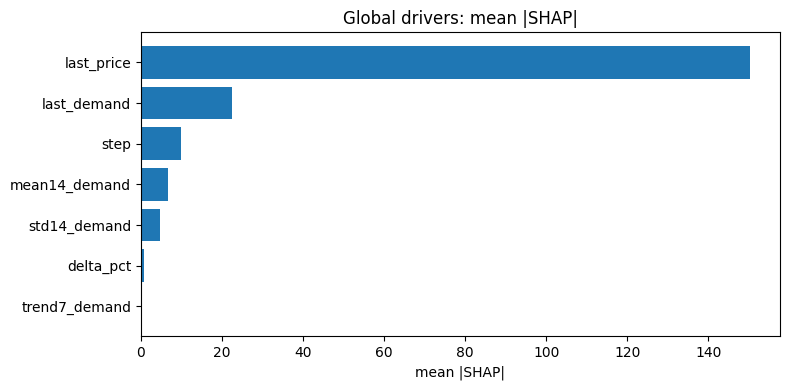

In [ ]:
topk = x_tbwisa_global_shap.head(12).sort_values("mean_abs_shap")
plt.figure(figsize=(8, 4))
plt.barh(topk["feature"], topk["mean_abs_shap"])
plt.title("Global drivers: mean |SHAP|")
plt.xlabel("mean |SHAP|")
plt.tight_layout()
plt.savefig(OUT_DIR / "x_tbwisa_global_shap.png", dpi=160, bbox_inches="tight")
plt.show()

## Local TreeSHAP waterfall at the decision point

This figure uses the first valid held-out SKU as a representative case. The selected local sample corresponds to the highest-scoring delta and the first step inside the recommended reference window whenever possible.


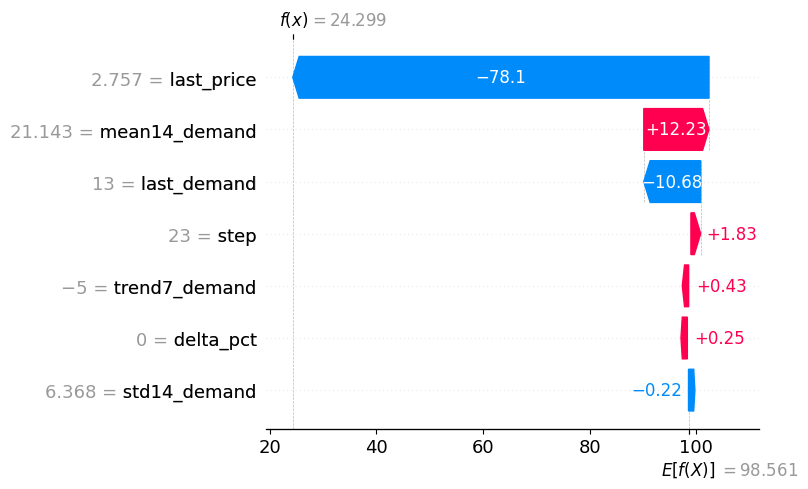

In [ ]:
case_sku = str(case_payload["sku"])
case_sur = sur_df.loc[sur_df["sku"].astype(str) == case_sku].copy().reset_index(drop=True)
case_mask = sur_df["sku"].astype(str) == case_sku
case_shap = shap_vals[case_mask.values, :]
case_win = windows_df.loc[windows_df["sku"].astype(str) == case_sku].copy().reset_index(drop=True)

best_case = case_win.sort_values("score", ascending=False).iloc[0]
case_delta = int(best_case["delta_pct"])
case_step = int(best_case["start"]) + 1

local_mask = (case_sur["delta_pct"].astype(int) == case_delta) & (case_sur["step"].astype(int) == case_step)
if local_mask.sum() == 0:
    local_mask = case_sur["delta_pct"].astype(int) == case_delta
local_idx = int(np.where(local_mask.values)[0][0])

row = case_sur.iloc[local_idx][FEATURES]
values = case_shap[local_idx]
base_value = explainer.expected_value
try:
    exp = shap.Explanation(values=values, base_values=base_value, data=row.values, feature_names=FEATURES)
    plt.figure()
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "x_tbwisa_local_waterfall.png", dpi=160, bbox_inches="tight")
    plt.show()
except Exception:
    # Robust fallback if the waterfall API differs
    local_df = pd.DataFrame({"feature": FEATURES, "shap_value": values}).sort_values("shap_value", key=np.abs, ascending=False).head(10)
    plt.figure(figsize=(8, 4))
    plt.barh(local_df["feature"][::-1], local_df["shap_value"][::-1])
    plt.title(f"Local TreeSHAP at decision point (SKU={case_sku}, delta={case_delta}%)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "x_tbwisa_local_waterfall.png", dpi=160, bbox_inches="tight")
    plt.show()

## Adjacent-delta SHAP distance (normalized L1)

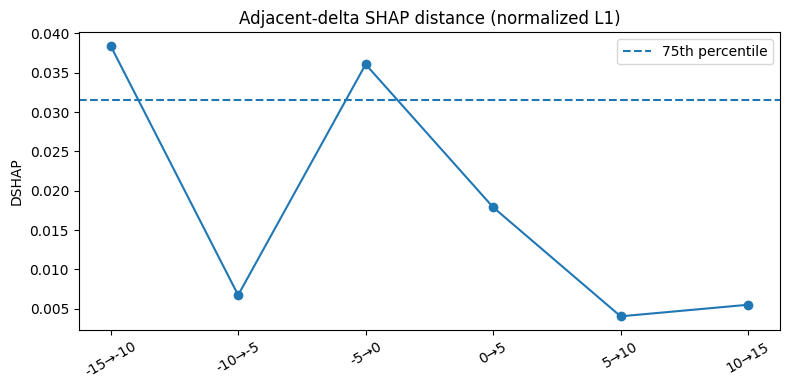

In [ ]:
drift_plot = (
    drift_df.groupby(["delta_a", "delta_b"])["dshap"]
    .mean()
    .reset_index()
)
labels = drift_plot.apply(lambda r: f"{int(r['delta_a'])}→{int(r['delta_b'])}", axis=1)

plt.figure(figsize=(8, 4))
plt.plot(labels, drift_plot["dshap"], marker="o")
plt.axhline(drift_plot["dshap"].quantile(DRIFT_Q), linestyle="--", label=f"{int(DRIFT_Q*100)}th percentile")
plt.title("Adjacent-delta SHAP distance (normalized L1)")
plt.ylabel("DSHAP")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "x_tbwisa_adjacent_delta_drift.png", dpi=160, bbox_inches="tight")
plt.show()

## X-TBWISA screening outcomes across intervention scenarios

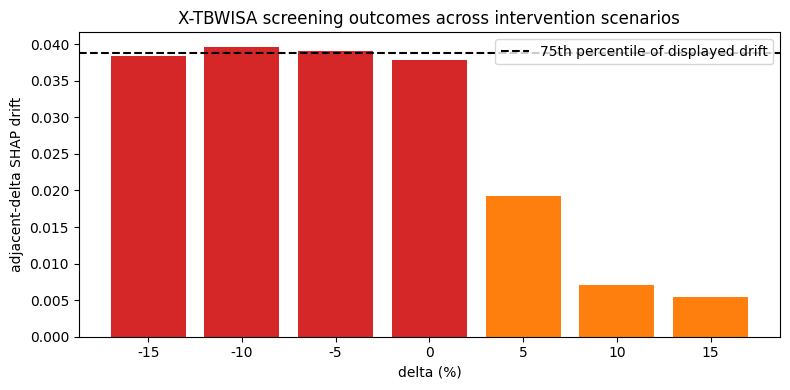

In [ ]:
screen_plot = x_tbwisa_screening_summary.copy()
color_map = {"Accept": "#2ca02c", "Accept_Caution": "#ff7f0e", "Flag": "#d62728"}

plt.figure(figsize=(8, 4))
plt.bar(
    screen_plot["delta_pct"].astype(str),
    screen_plot["dshap"],
    color=[color_map.get(v, "#1f77b4") for v in screen_plot["decision"]],
)
plt.axhline(screen_plot["dshap"].quantile(DRIFT_Q), linestyle="--", color="black", label=f"{int(DRIFT_Q*100)}th percentile of displayed drift")
plt.title("X-TBWISA screening outcomes across intervention scenarios")
plt.xlabel("delta (%)")
plt.ylabel("adjacent-delta SHAP drift")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "x_tbwisa_screening_outcomes.png", dpi=160, bbox_inches="tight")
plt.show()

## Export summary

In [ ]:
print("Files written to:", OUT_DIR.resolve())
for p in sorted(OUT_DIR.glob("*")):
    print("-", p.name)

Files written to: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/x_tbwisa_validation_outputs
- x_tbwisa_adjacent_delta_drift.png
- x_tbwisa_drift_pairs_by_sku.csv
- x_tbwisa_fidelity.csv
- x_tbwisa_fidelity.png
- x_tbwisa_global_shap.csv
- x_tbwisa_global_shap.png
- x_tbwisa_local_waterfall.png
- x_tbwisa_price_drift_by_sku.csv
- x_tbwisa_screening_by_sku.csv
- x_tbwisa_screening_outcomes.png
- x_tbwisa_screening_summary.csv
- x_tbwisa_status_distribution.csv
- x_tbwisa_surrogate_dataset.csv
